In [2]:
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# note to Mykola: this is the corrected data set. 
df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop_cleaned_chi2_only.csv")
y = df["residuals"]

In [4]:
all_features = [
    "ZTF_x1",
    "ZTF_c",
    "DESI_FASTSPEC_LOGMSTAR",
    "DESI_FASTSPEC_SFR",
    "DESI_FASTSPEC_VDISP",
    "DESI_FASTSPEC_DN4000",
    "DESI_FASTSPEC_g_minus_r",
    "DESI_FASTSPEC_AGE",
    "DESI_METADATA_Z"
]

short_names = {
    "ZTF_x1": "x₁",
    "ZTF_c": "c",
    "DESI_FASTSPEC_LOGMSTAR": "logM★",
    "DESI_FASTSPEC_SFR": "SFR",
    "DESI_FASTSPEC_VDISP": "σ_v",
    "DESI_FASTSPEC_DN4000": "Dn4000",
    "DESI_FASTSPEC_g_minus_r": "g−r",
    "DESI_FASTSPEC_AGE": "Age",
    "DESI_METADATA_Z": "z"
}

best_params = {'n_estimators': 600, 'max_depth': 26, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': True, 'max_samples': 0.5041681530892771}


X = df[all_features]
rf = RandomForestRegressor(**best_params)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_,index=all_features).sort_values(ascending=False)

print("Feature Importances (MDI):")
print(importances)


Feature Importances (MDI):
ZTF_c                      0.198913
DESI_FASTSPEC_g_minus_r    0.145304
DESI_METADATA_Z            0.143538
ZTF_x1                     0.107508
DESI_FASTSPEC_DN4000       0.104925
DESI_FASTSPEC_LOGMSTAR     0.104585
DESI_FASTSPEC_VDISP        0.072586
DESI_FASTSPEC_AGE          0.063886
DESI_FASTSPEC_SFR          0.058754
dtype: float64


Baseline RMS (no ML): 0.1867


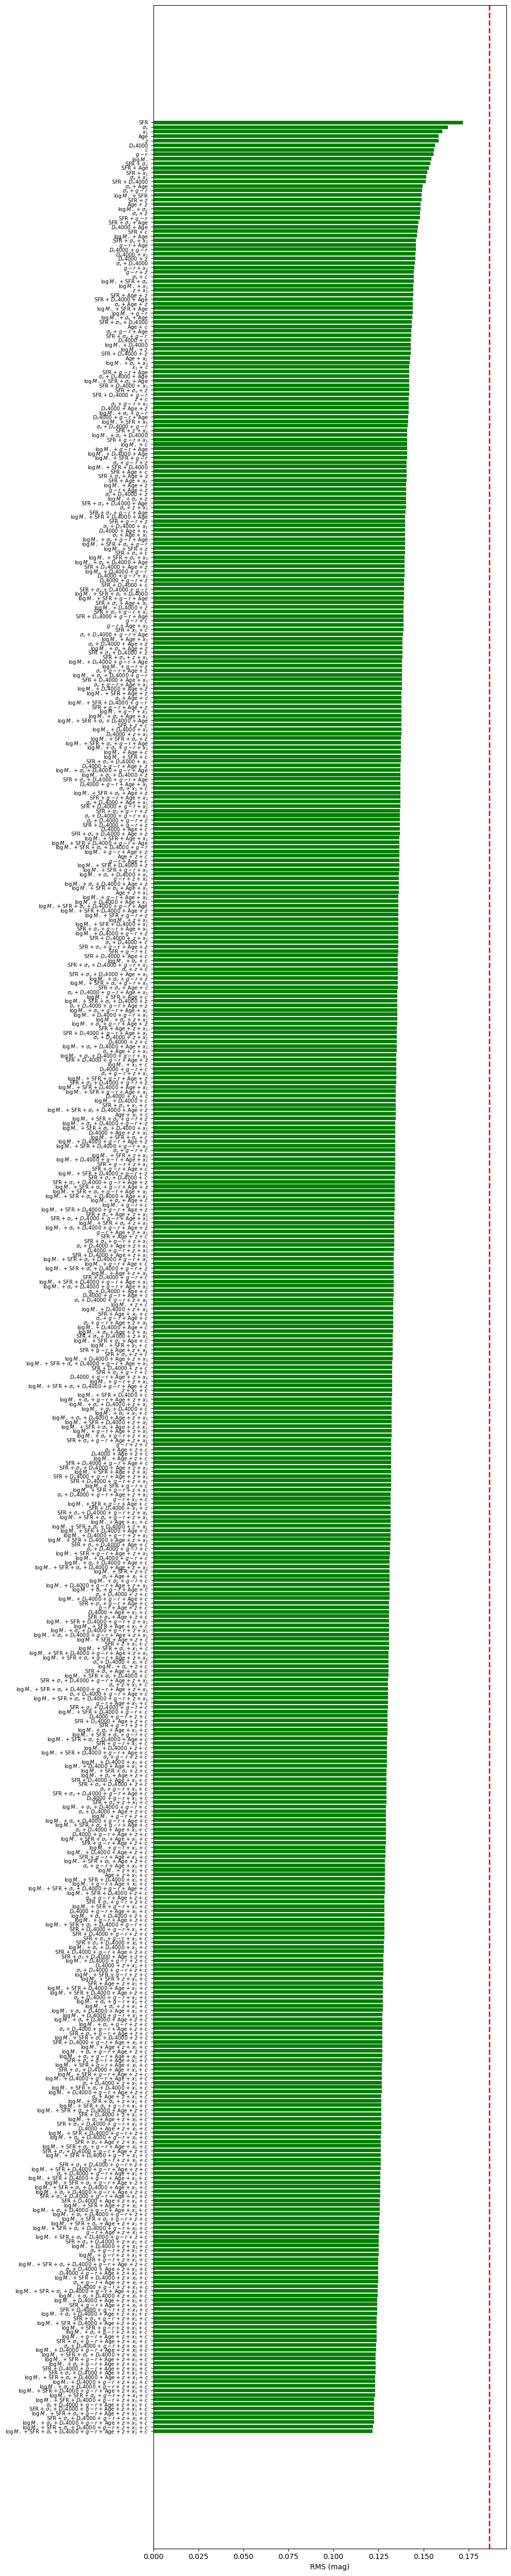

In [22]:
# Rename the DataFrame columns once. This is simply done
# because when produce the final plot for this problem
# we will end up wanting to get something that looks good with like nicely
# labeled axes.  
df = df.rename(columns={
    "DESI_FASTSPEC_LOGMSTAR":  r"$\log M_\star$",
    "DESI_FASTSPEC_SFR":       "SFR",
    "DESI_FASTSPEC_VDISP":     r"$\sigma_v$",
    "DESI_FASTSPEC_DN4000":    r"$D_n4000$",
    "DESI_FASTSPEC_g_minus_r": r"$g - r$",
    "DESI_FASTSPEC_AGE":       "Age",
    "DESI_METADATA_Z":          r"$z$",
    "ZTF_x1":                  r"$x_1$",
    "ZTF_c":                   r"$c$",
})

# Baseline: RMS with no ML just the pure RMS of the Tripp Corrected residuals. 
rms_baseline = np.sqrt(np.mean(df["residuals"] ** 2))
print(f"Baseline RMS (no ML): {rms_baseline:.4f}")


# Best parameters taken from another notebook. 
best_params = {'n_estimators': 600, 'max_depth': 26, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': True, 'max_samples': 0.5041681530892771}

# Just naming all features with their new names.
# Apparantly ou can get away with doing stuff like this using 
# pandas data frames. 
all_features = [
    r"$\log M_\star$",
    "SFR",
    r"$\sigma_v$",
    r"$D_n4000$",
    r"$g - r$",
    "Age",
    r"$z$",
    r"$x_1$",
    r"$c$",
]

results = []

# Outer loop goes through all 9 features. This will be numbers 1 through 9.
for n_feat in range(1, len(all_features) + 1):
    # Goes through every unique (i.e. no combo has exactly same fatures or repetas in different orders)
    # Computes (9 choose n_feat). 
    # combinations returns tuples of all_features of length n_feat. Ex. if n_feat = 3 it will return all 
    # unique combinations of 3 features.
    for combo in combinations(all_features, n_feat):
        
        # Converting toupls to list b/c it makes collumn selection easier. 
        combo_list = list(combo)

        # Only selects the features to be trained in the selection of features
        # chosen by the combinatronix loop.
        X_combo = df[combo_list]

        rf = RandomForestRegressor(**best_params) # Define
        rf.fit(X_combo, y) # Train
        y_pred_combo = rf.predict(X_combo) # Predict

        # Compute the RMS to ascertan the performance of the ML model. 
        ml_modified_residuals = df["residuals"] - y_pred_combo
        rms = np.sqrt(np.mean(ml_modified_residuals ** 2))

        # creates a lable fro the plot that separates each host galaxy feature by a plus sign. 
        label = " + ".join(combo_list)
        results.append({"features": label, "n_features": len(combo_list), "rms": rms})

# Saves final combo list data frame and sorts values from low to high based on RMS.
results_df = pd.DataFrame(results).sort_values("rms", ascending=True)
results_df.to_csv("data/feature_subset_sweep.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 50))

# Horizontal bar graph. 
# Have to parse in (coordinates of bars, width of bars)
ax.barh(range(len(results_df)), results_df["rms"], color="green")
ax.set_yticks(range(len(results_df)))
ax.set_yticklabels(results_df["features"], fontsize=7)

# Vertical Line for Our Baseline Plot.
ax.axvline(rms_baseline, color="red", linestyle="--", linewidth=2, label=f"No ML: {rms_baseline:.4f}")
ax.set_xlabel("RMS (mag)")
plt.tight_layout()
plt.show()

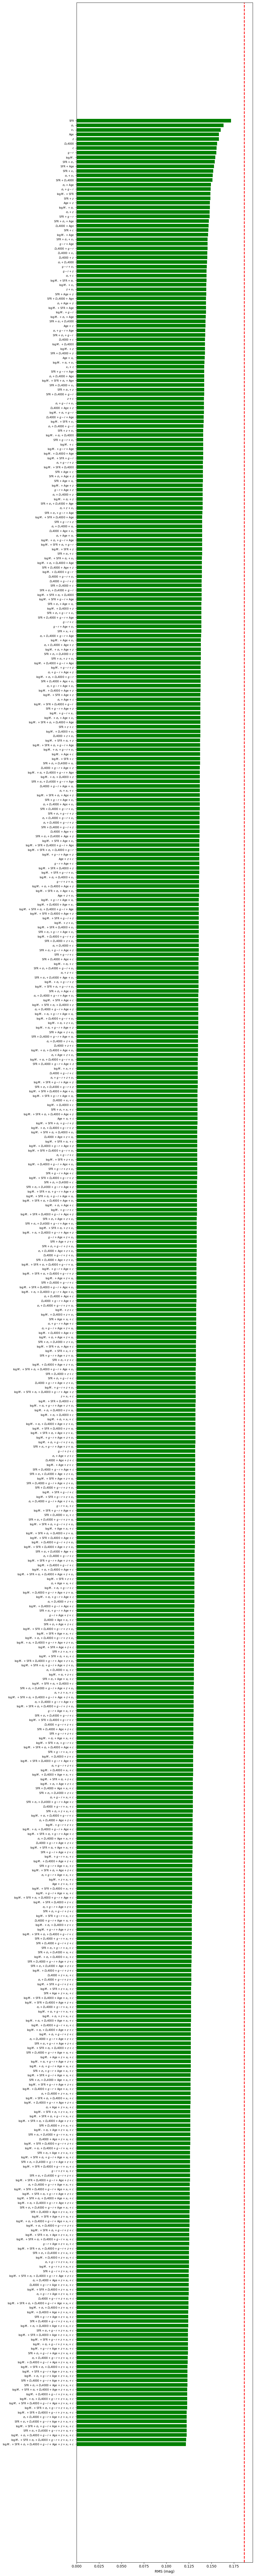

In [25]:

fig, ax = plt.subplots(figsize=(10, 100))

# Horizontal bar graph. 
# Have to parse in (coordinates of bars, width of bars)
ax.barh(range(len(results_df)), results_df["rms"], color="green")
ax.set_yticks(range(len(results_df)))
ax.set_yticklabels(results_df["features"], fontsize=7)

# Vertical Line for Our Baseline Plot.
ax.axvline(rms_baseline, color="red", linestyle="--", linewidth=2, label=f"No ML: {rms_baseline:.4f}")
ax.set_xlabel("RMS (mag)")
plt.tight_layout()
plt.savefig("figures/feature_subset_sweep.pdf")
plt.show()

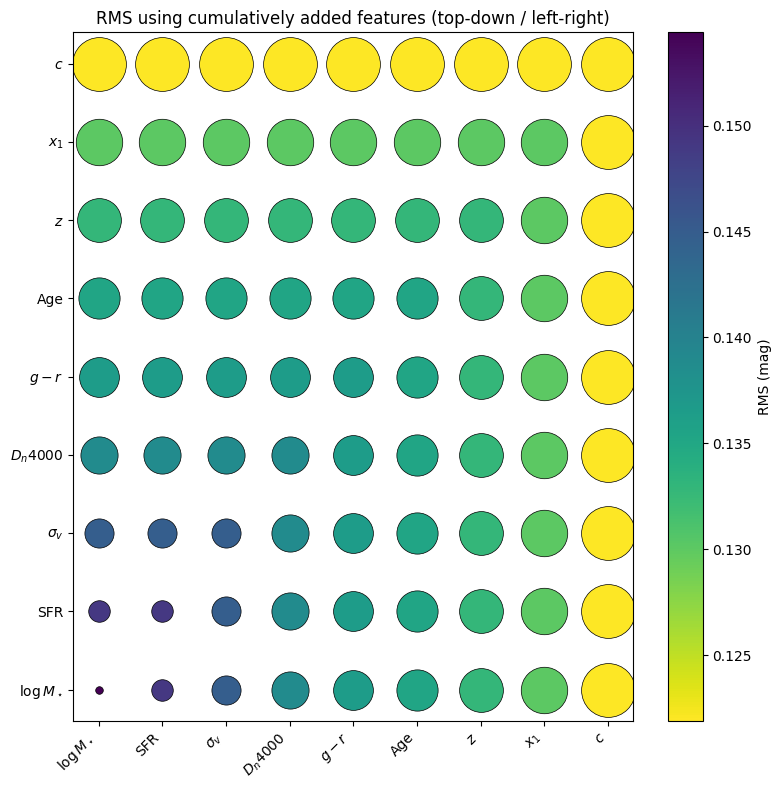

In [14]:
n = len(all_features)
grid_rms = np.full((n, n), np.nan)

# Precompute cumulative RMS once (we only need n values, not n²)
cumulative = []
for k in range(1, n + 1):
    feats = all_features[:k]
    params = best_params.copy()
    if params["max_features"] is None and len(feats) < 3:
        params["max_features"] = len(feats)
    X_combo = df[feats]
    rf = RandomForestRegressor(**params)
    rf.fit(X_combo, y)
    rms = np.sqrt(np.mean((df["residuals"] - rf.predict(X_combo)) ** 2))
    cumulative.append(rms)

# Fill the grid: cell (i, j) corresponds to having features 0..max(i, j)
for i in range(n):
    for j in range(n):
        grid_rms[i, j] = cumulative[max(i, j)]

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
vmin, vmax = np.nanmin(grid_rms), np.nanmax(grid_rms)
for i in range(n):
    for j in range(n):
        size = 1500 * (vmax - grid_rms[i, j]) / (vmax - vmin) if vmax > vmin else 500
        ax.scatter(j, i, s=max(size, 30), c=[grid_rms[i, j]],
                   cmap="viridis_r", vmin=vmin, vmax=vmax,
                   edgecolor="k", linewidth=0.5)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(all_features, rotation=45, ha="right")
ax.set_yticklabels(all_features)
ax.set_title("RMS using cumulatively added features (top-down / left-right)")

sm = plt.cm.ScalarMappable(cmap="viridis_r",
                            norm=plt.Normalize(vmin=vmin, vmax=vmax))
plt.colorbar(sm, ax=ax, label="RMS (mag)")
plt.tight_layout()
plt.show()